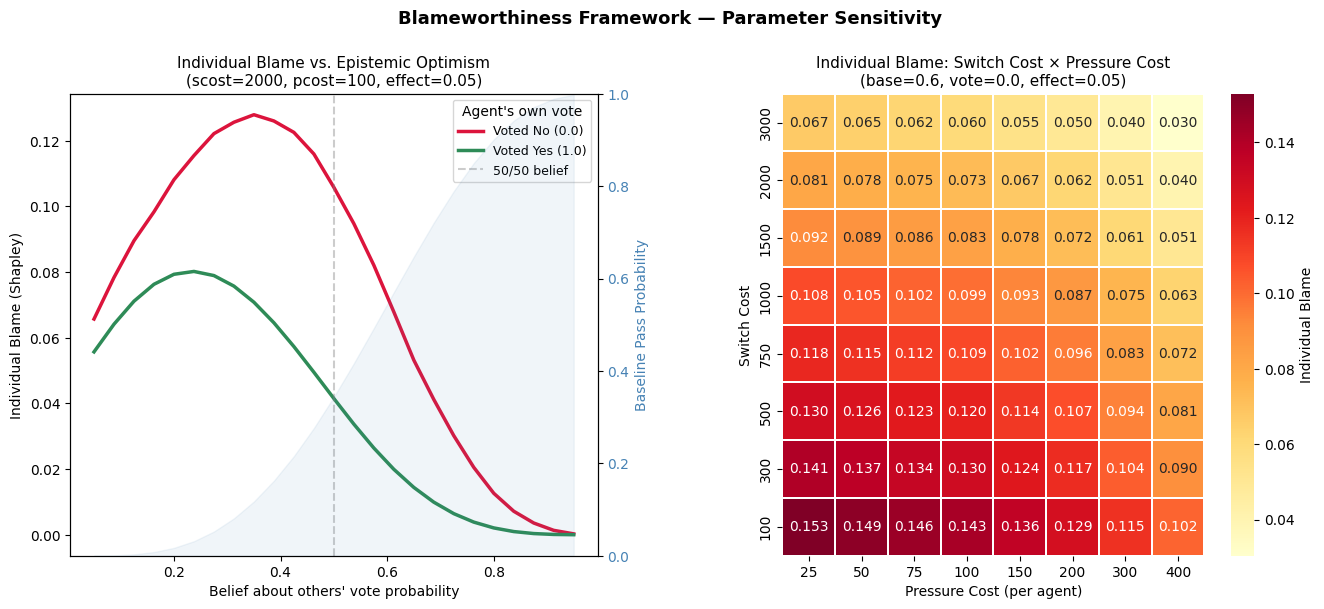

In [2]:
import itertools, math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from committee import BlameCalculator, EpistemicState

# --- paste or import the classes above this point ---
OUT_DIR = 'plots'

AGENTS = ['ag1', 'ag2', 'ag3', 'ag4', 'ag5', 'ag6', 'ag7']
TARGET = 'ag1'
N = 5000

# ── Plot 1 data: sweep base from 0.05 → 0.95 ─────────────────────────────────
base_values = np.linspace(0.05, 0.95, 25)
records1 = []

for base in base_values:
    for vote_label, vote_val in [('Voted No (0.0)', 0.0), ('Voted Yes (1.0)', 1.0)]:
        calc = BlameCalculator(AGENTS, N, pressure_effect=0.05, pressure_cost=100, switch_cost=2000)
        probs = {ag: base for ag in AGENTS}
        probs[TARGET] = vote_val
        e1 = EpistemicState(probs)
        blame = calc.apportion_blame_shapley(TARGET, e1)
        records1.append({
            'Belief about others (base)': base,
            'Own vote': vote_label,
            'Individual Blame': blame,
            'Baseline Pass Prob': e1.get_outcome_probability(),
        })

df1 = pd.DataFrame(records1)

# ── Plot 2 data: sweep scost × pcost ─────────────────────────────────────────
scost_values = [100, 300, 500, 750, 1000, 1500, 2000, 3000]
pcost_values = [25,  50,  75, 100,  150,  200,  300,  400]
records2 = []

for scost in scost_values:
    for pcost in pcost_values:
        calc = BlameCalculator(AGENTS, N, pressure_effect=0.05, pressure_cost=pcost, switch_cost=scost)
        probs = {ag: 0.6 for ag in AGENTS}
        probs[TARGET] = 0.0          # agent voted no — worst case for blame
        e1 = EpistemicState(probs)
        blame = calc.apportion_blame_shapley(TARGET, e1)
        records2.append({'Switch Cost': scost, 'Pressure Cost': pcost, 'Individual Blame': blame})

df2 = pd.DataFrame(records2)
pivot = df2.pivot(index='Switch Cost', columns='Pressure Cost', values='Individual Blame')

# ── Draw ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 6))
gs = GridSpec(1, 2, figure=fig, wspace=0.35)

# --- Plot 1: line plot with dual-layer (blame + pass prob as background) -----
ax1 = fig.add_subplot(gs[0])
ax1b = ax1.twinx()

# Pass probability as a faint reference band (same for both vote conditions since
# it's computed from *others'* beliefs — plot just the no-vote variant)
ref = df1[df1['Own vote'] == 'Voted No (0.0)']
ax1b.fill_between(ref['Belief about others (base)'],
                  ref['Baseline Pass Prob'],
                  alpha=0.08, color='steelblue', label='Pass Prob (ref)')
ax1b.set_ylabel('Baseline Pass Probability', color='steelblue', fontsize=10)
ax1b.tick_params(axis='y', labelcolor='steelblue')
ax1b.set_ylim(0, 1)

sns.lineplot(data=df1, x='Belief about others (base)', y='Individual Blame',
             hue='Own vote', palette=['crimson', 'seagreen'],
             linewidth=2.5, ax=ax1)

ax1.set_title('Individual Blame vs. Epistemic Optimism\n(scost=2000, pcost=100, effect=0.05)', fontsize=11)
ax1.set_xlabel('Belief about others\' vote probability')
ax1.set_ylabel('Individual Blame (Shapley)')
ax1.axvline(x=0.5, color='gray', linestyle='--', alpha=0.4, label='50/50 belief')
ax1.legend(title='Agent\'s own vote', fontsize=9)

# --- Plot 2: heatmap -----------------------------------------------------------
ax2 = fig.add_subplot(gs[1])
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Individual Blame'},
            ax=ax2)
ax2.set_title('Individual Blame: Switch Cost × Pressure Cost\n(base=0.6, vote=0.0, effect=0.05)', fontsize=11)
ax2.set_xlabel('Pressure Cost (per agent)')
ax2.set_ylabel('Switch Cost')
ax2.invert_yaxis()

plt.suptitle('Blameworthiness Framework — Parameter Sensitivity', fontsize=13, fontweight='bold', y=1.02)
plt.savefig(f'{OUT_DIR}/blame_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

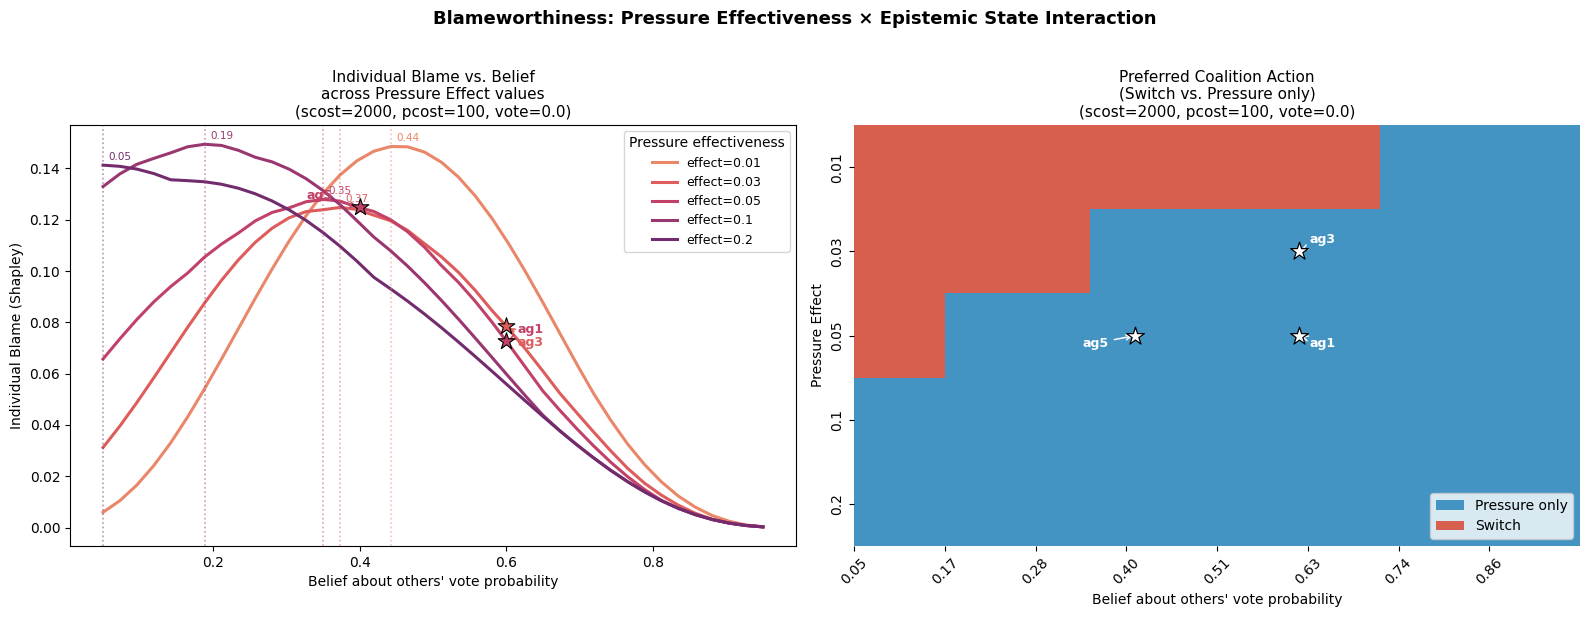

Paper agent blame values (vote=no, pcost=100, scost=2000):
  ag1  base=0.6  effect=0.05  → blame=0.0727
  ag3  base=0.6  effect=0.03  → blame=0.0785
  ag5  base=0.4  effect=0.05  → blame=0.1248


In [3]:

# ── Plot 3: base × effect interaction ─────────────────────────────────────────
# Annotated with paper agents: ag1 (base=0.6, effect=0.05), ag3 (base=0.6, effect=0.03), ag5 (base=0.4, effect=0.05)

effect_values = [0.01, 0.03, 0.05, 0.10, 0.20]
base_values3 = np.linspace(0.05, 0.95, 40)
records3 = []

for effect in effect_values:
    for base in base_values3:
        calc = BlameCalculator(AGENTS, N, pressure_effect=effect, pressure_cost=100, switch_cost=2000)
        probs = {ag: base for ag in AGENTS}
        probs[TARGET] = 0.0
        e1 = EpistemicState(probs)
        blame = calc.apportion_blame_shapley(TARGET, e1)

        e_pressure, cost_p = calc.simulate_action(AGENTS, e1, switcher_id=None, target_id=TARGET)
        e_switch, cost_s   = calc.simulate_action(AGENTS, e1, switcher_id=TARGET, target_id=TARGET)
        gb_pressure = calc.delta(e1, e_pressure) * ((N - cost_p) / N)
        gb_switch   = calc.delta(e1, e_switch)   * ((N - cost_s) / N)
        preferred = 'Switch' if gb_switch > gb_pressure else 'Pressure only'

        records3.append({
            'Belief about others (base)': base,
            'Pressure Effect': effect,
            'effect_label': f'effect={effect}',
            'Individual Blame': blame,
            'Preferred action': preferred,
        })

df3 = pd.DataFrame(records3)

# ── Compute exact blame for paper agents ──────────────────────────────────────
paper_agents = {
    'ag1': {'base': 0.6, 'effect': 0.05},
    'ag3': {'base': 0.6, 'effect': 0.03},
    'ag5': {'base': 0.4, 'effect': 0.05},
}
for name, cfg in paper_agents.items():
    c = BlameCalculator(AGENTS, N, pressure_effect=cfg['effect'], pressure_cost=100, switch_cost=2000)
    p = {ag: cfg['base'] for ag in AGENTS}
    p[TARGET] = 0.0
    e = EpistemicState(p)
    cfg['blame'] = c.apportion_blame_shapley(TARGET, e)

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

palette = sns.color_palette('flare', n_colors=len(effect_values))
effect_color = {e: palette[i] for i, e in enumerate(effect_values)}

ax = axes[0]
sns.lineplot(data=df3, x='Belief about others (base)', y='Individual Blame',
             hue='effect_label', palette=palette, linewidth=2.2, ax=ax)

# Mark peaks
for i, effect in enumerate(effect_values):
    sub = df3[df3['Pressure Effect'] == effect]
    peak_row = sub.loc[sub['Individual Blame'].idxmax()]
    ax.axvline(peak_row['Belief about others (base)'], color=palette[i],
               linestyle=':', alpha=0.5, linewidth=1.2)
    ax.annotate(f"{peak_row['Belief about others (base)']:.2f}",
                xy=(peak_row['Belief about others (base)'], peak_row['Individual Blame']),
                xytext=(4, 4), textcoords='offset points', fontsize=7.5, color=palette[i])

# Annotate paper agents as stars on their respective curves
offsets = {'ag1': (8, 6), 'ag3': (8, -14), 'ag5': (-38, 6)}
for name, cfg in paper_agents.items():
    col = effect_color[cfg['effect']]
    ax.scatter([cfg['base']], [cfg['blame']], s=160, marker='*', zorder=6,
               color=col, edgecolors='black', linewidths=0.8)
    dx, dy = offsets[name]
    ax.annotate(name, xy=(cfg['base'], cfg['blame']), xytext=(dx, dy),
                textcoords='offset points', fontsize=9, fontweight='bold', color=col,
                arrowprops=dict(arrowstyle='->', color=col, lw=1.1))

ax.set_title('Individual Blame vs. Belief\nacross Pressure Effect values\n(scost=2000, pcost=100, vote=0.0)', fontsize=11)
ax.set_xlabel("Belief about others' vote probability")
ax.set_ylabel('Individual Blame (Shapley)')
ax.legend(title='Pressure effectiveness', fontsize=9)

# --- Right: action phase diagram ─────────────────────────────────────────────
ax2 = axes[1]
df3['action_numeric'] = (df3['Preferred action'] == 'Switch').astype(int)
pivot3 = df3.pivot_table(index='Pressure Effect', columns='Belief about others (base)',
                          values='action_numeric', aggfunc='first')

sns.heatmap(pivot3, cmap=sns.color_palette(['#4393c3', '#d6604d'], as_cmap=True),
            linewidths=0, cbar=False, ax=ax2, yticklabels=effect_values)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4393c3', label='Pressure only'),
                   Patch(facecolor='#d6604d', label='Switch')]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=10)

# Annotate paper agents on the phase diagram
base_cols = pivot3.columns.values
eff_rows  = pivot3.index.values
hm_offsets = {'ag1': (8, -8), 'ag3': (8, 6), 'ag5': (-38, -8)}
for name, cfg in paper_agents.items():
    col_idx = np.argmin(np.abs(base_cols - cfg['base']))
    row_idx = np.argmin(np.abs(eff_rows  - cfg['effect']))
    x, y = col_idx + 0.5, row_idx + 0.5
    ax2.scatter([x], [y], s=180, marker='*', zorder=6,
                color='white', edgecolors='black', linewidths=0.9)
    dx, dy = hm_offsets[name]
    ax2.annotate(name, xy=(x, y), xytext=(dx, dy),
                 textcoords='offset points', fontsize=9, fontweight='bold', color='white',
                 arrowprops=dict(arrowstyle='->', color='white', lw=1.1))

ax2.set_title('Preferred Coalition Action\n(Switch vs. Pressure only)\n(scost=2000, pcost=100, vote=0.0)', fontsize=11)
ax2.set_xlabel("Belief about others' vote probability")
ax2.set_ylabel('Pressure Effect')

xtick_positions = range(0, len(pivot3.columns), 5)
ax2.set_xticks(list(xtick_positions))
ax2.set_xticklabels([f"{pivot3.columns[i]:.2f}" for i in xtick_positions], rotation=45)

plt.suptitle('Blameworthiness: Pressure Effectiveness × Epistemic State Interaction',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/blame_effect_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

print("Paper agent blame values (vote=no, pcost=100, scost=2000):")
for name, cfg in paper_agents.items():
    print(f"  {name}  base={cfg['base']}  effect={cfg['effect']}  → blame={cfg['blame']:.4f}")


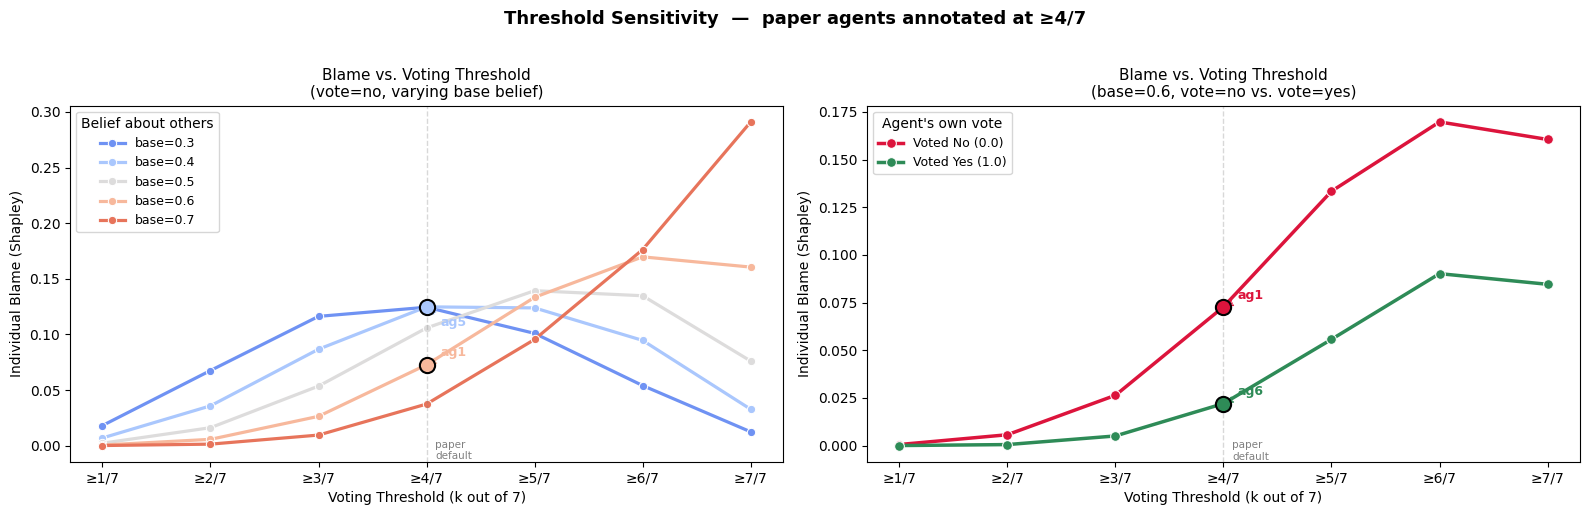

ag1 blame at ≥4/7 (vote=no,  base=0.6): 0.0727
ag5 blame at ≥4/7 (vote=no,  base=0.4): 0.1248
ag1 blame at ≥4/7 (vote=no,  base=0.6): 0.0727
ag6 blame at ≥4/7 (vote=yes, base=0.6): 0.0220


In [4]:

# ── Plot 4: How does blame change as the voting threshold increases? ───────────
# Sweep threshold from 1/7 to 7/7 and observe individual blame.
# Left:  multiple base values, agent voted no
# Right: base=0.6, vote=no vs vote=yes
# Annotated: agents from committee.py sit at threshold=4 (the paper's default)

class ThresholdEpistemicState(EpistemicState):
    def __init__(self, probabilities_dict, threshold=4):
        super().__init__(probabilities_dict)
        self.threshold = threshold

    def get_outcome_probability(self) -> float:
        agents = list(self.probs.keys())
        pass_prob = 0.0
        for i in range(len(agents) + 1):
            for yes_voters in itertools.combinations(agents, i):
                if len(yes_voters) >= self.threshold:
                    world_prob = 1.0
                    for ag in agents:
                        world_prob *= self.probs[ag] if ag in yes_voters else (1.0 - self.probs[ag])
                    pass_prob += world_prob
        return pass_prob

def blame_for_threshold(threshold, probs, vote_val, agents, N):
    calc = BlameCalculator(agents, N, pressure_effect=0.05, pressure_cost=100, switch_cost=2000)
    probs_copy = probs.copy()
    probs_copy[TARGET] = vote_val
    e1 = ThresholdEpistemicState(probs_copy, threshold=threshold)

    original_simulate = calc.simulate_action
    def simulate_with_threshold(coalition_ids, base_state, switcher_id=None, target_id=None):
        e2_raw, cost = original_simulate(coalition_ids, base_state,
                                         switcher_id=switcher_id, target_id=target_id)
        return ThresholdEpistemicState(e2_raw.probs, threshold=threshold), cost
    calc.simulate_action = simulate_with_threshold

    return calc.apportion_blame_shapley(TARGET, e1)

thresholds  = list(range(1, 8))
base_vals_t = [0.3, 0.4, 0.5, 0.6, 0.7]
records4    = []

for threshold in thresholds:
    for base in base_vals_t:
        probs = {ag: base for ag in AGENTS}
        blame = blame_for_threshold(threshold, probs, vote_val=0.0, agents=AGENTS, N=N)
        records4.append({'Threshold': threshold, 'base_label': f'base={base}',
                         'panel': 'left', 'Individual Blame': blame})

    for vote_label, vote_val in [('Voted No (0.0)', 0.0), ('Voted Yes (1.0)', 1.0)]:
        probs = {ag: 0.6 for ag in AGENTS}
        blame = blame_for_threshold(threshold, probs, vote_val=vote_val, agents=AGENTS, N=N)
        records4.append({'Threshold': threshold, 'base_label': vote_label,
                         'panel': 'right', 'Individual Blame': blame})

df4 = pd.DataFrame(records4)

# ── Look up agent positions at threshold=4 (the paper's default) ──────────────
# Left plot: ag1 (base=0.6, vote=no), ag5 (base=0.4, vote=no)
ag1_left  = df4[(df4['panel'] == 'left') & (df4['base_label'] == 'base=0.6') & (df4['Threshold'] == 4)]['Individual Blame'].values[0]
ag5_left  = df4[(df4['panel'] == 'left') & (df4['base_label'] == 'base=0.4') & (df4['Threshold'] == 4)]['Individual Blame'].values[0]
# Right plot: ag1 (vote=no, base=0.6), ag6 (vote=yes, base=0.6)
ag1_right = df4[(df4['panel'] == 'right') & (df4['base_label'] == 'Voted No (0.0)') & (df4['Threshold'] == 4)]['Individual Blame'].values[0]
ag6_right = df4[(df4['panel'] == 'right') & (df4['base_label'] == 'Voted Yes (1.0)') & (df4['Threshold'] == 4)]['Individual Blame'].values[0]

# ── Draw ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette_left = sns.color_palette('coolwarm', n_colors=len(base_vals_t))

sns.lineplot(data=df4[df4['panel'] == 'left'],
             x='Threshold', y='Individual Blame', hue='base_label',
             palette=palette_left, linewidth=2.3, marker='o', markersize=6, ax=axes[0])

# ag1 sits on base=0.6 curve (index 3), ag5 on base=0.4 (index 1)
axes[0].scatter([4], [ag1_left], s=120, zorder=6, color=palette_left[3],
                edgecolors='black', linewidths=1.5)
axes[0].annotate('ag1', xy=(4, ag1_left), xytext=(10, 6),
                 textcoords='offset points', fontsize=9, fontweight='bold',
                 color=palette_left[3],
                 arrowprops=dict(arrowstyle='->', color=palette_left[3], lw=1.2))

axes[0].scatter([4], [ag5_left], s=120, zorder=6, color=palette_left[1],
                edgecolors='black', linewidths=1.5)
axes[0].annotate('ag5', xy=(4, ag5_left), xytext=(10, -14),
                 textcoords='offset points', fontsize=9, fontweight='bold',
                 color=palette_left[1],
                 arrowprops=dict(arrowstyle='->', color=palette_left[1], lw=1.2))

axes[0].axvline(x=4, color='gray', linestyle='--', alpha=0.3, linewidth=1)
axes[0].text(4.08, axes[0].get_ylim()[0] + 0.002, 'paper\ndefault', fontsize=7.5, color='gray')

axes[0].set_title('Blame vs. Voting Threshold\n(vote=no, varying base belief)', fontsize=11)
axes[0].set_xlabel('Voting Threshold (k out of 7)')
axes[0].set_ylabel('Individual Blame (Shapley)')
axes[0].set_xticks(thresholds)
axes[0].set_xticklabels([f'≥{k}/7' for k in thresholds])
axes[0].legend(title='Belief about others', fontsize=9)

sns.lineplot(data=df4[df4['panel'] == 'right'],
             x='Threshold', y='Individual Blame', hue='base_label',
             palette=['crimson', 'seagreen'], linewidth=2.5, marker='o', markersize=7, ax=axes[1])

axes[1].scatter([4], [ag1_right], s=120, zorder=6, color='crimson',
                edgecolors='black', linewidths=1.5)
axes[1].annotate('ag1', xy=(4, ag1_right), xytext=(10, 6),
                 textcoords='offset points', fontsize=9, fontweight='bold', color='crimson',
                 arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2))

axes[1].scatter([4], [ag6_right], s=120, zorder=6, color='seagreen',
                edgecolors='black', linewidths=1.5)
axes[1].annotate('ag6', xy=(4, ag6_right), xytext=(10, 6),
                 textcoords='offset points', fontsize=9, fontweight='bold', color='seagreen',
                 arrowprops=dict(arrowstyle='->', color='seagreen', lw=1.2))

axes[1].axvline(x=4, color='gray', linestyle='--', alpha=0.3, linewidth=1)
axes[1].text(4.08, axes[1].get_ylim()[0] + 0.001, 'paper\ndefault', fontsize=7.5, color='gray')

axes[1].set_title('Blame vs. Voting Threshold\n(base=0.6, vote=no vs. vote=yes)', fontsize=11)
axes[1].set_xlabel('Voting Threshold (k out of 7)')
axes[1].set_ylabel('Individual Blame (Shapley)')
axes[1].set_xticks(thresholds)
axes[1].set_xticklabels([f'≥{k}/7' for k in thresholds])
axes[1].legend(title="Agent's own vote", fontsize=9)

plt.suptitle('Threshold Sensitivity  —  paper agents annotated at ≥4/7',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/blame_threshold.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"ag1 blame at ≥4/7 (vote=no,  base=0.6): {ag1_left:.4f}")
print(f"ag5 blame at ≥4/7 (vote=no,  base=0.4): {ag5_left:.4f}")
print(f"ag1 blame at ≥4/7 (vote=no,  base=0.6): {ag1_right:.4f}")
print(f"ag6 blame at ≥4/7 (vote=yes, base=0.6): {ag6_right:.4f}")
